# Game of Thoughts: Demo and Evaluation 

This notebook demonstrates the main components of the project:
- rule understanding
- rule error detection
- move simulation
- game generation

The implementation logic is contained in the main Python modules
This notebook only imports those modules and shows example usage, results, and visualizations.


In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)


Project root: /workspaces/game-of-thoughts


In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

from src.evaluation.rule_metrics import score_rule_summary, score_error_detection
from src.evaluation.generation_metrics import evaluate_generated_game


In [3]:
from pathlib import Path

# 1. Define the Root (The anchor for everything)
BASE_DIR = ROOT 

# 2. Main Results Directories
RESULTS_DIR   = BASE_DIR / "results"
PLOTS_DIR     = RESULTS_DIR / "plots"
TABLES_DIR    = RESULTS_DIR / "tables"     # Source of truth for .csv files
RESPONSES_DIR = RESULTS_DIR / "responses"

# 3. Specific Experiment Sub-directories (Where the .txt and .json files live)
# Matches your screenshot: results/responses/...
GENERATION_DIR     = RESPONSES_DIR / "game_generation"
RULE_ERROR_DIR     = RESPONSES_DIR / "rule_error_detection"
RULE_UNDERSTAND_DIR = RESPONSES_DIR / "rule_understanding"
SIMULATION_DIR      = RESPONSES_DIR / "simulation"

# 4. Analysis & Data (Optional/Future-proofing)
# Based on your structure, 'analysis' usually lives inside 'src', 
# but if you want a folder for temporary analysis outputs:
ANALYSIS_DIR  = RESULTS_DIR / "analysis" 
DATA_DIR      = BASE_DIR / "data" / "processed"

# Create directories if they don't exist (safety check)
for folder in [PLOTS_DIR, TABLES_DIR, ANALYSIS_DIR, DATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Verification Print
print(f"✅ Paths mapped to: {RESULTS_DIR}")

✅ Paths mapped to: /workspaces/game-of-thoughts/results


## 1. Rule Understanding

This section evaluates whether a model correctly captures the main rules of a game.
The evaluation compares model outputs against a gold rule schema.


In [12]:
import json
from src.evaluation.rule_metrics import score_rule_summary

# 1. Map to your structured Data and Responses folders
# Note: 'data/processed/tictactoe' for the schema
schema_path = DATA_DIR / "tictactoe" / "rule_schema_tictactoe.json"

# Matches 'results/responses/rule_understanding' from your registry
response_path = RULE_UNDERSTAND_DIR / "rule_understanding_tictactoe_llama-3.1-8b-instant.txt"

# 2. Load the files
if not schema_path.exists():
    print(f" Error: Schema not found at {schema_path}")
elif not response_path.exists():
    print(f" Error: Response file not found at {response_path}")
else:
    # Read and parse
    schema = json.loads(schema_path.read_text(encoding="utf-8"))
    model_output = response_path.read_text(encoding="utf-8")

    # 3. Execute Scoring
    rule_understanding_result = score_rule_summary(model_output, schema)
    
    # Display the result
    display(rule_understanding_result)

{'completeness': 0.5,
 'precision': 0.5714285714285714,
 'f1': 0.5333333333333333,
 'correct_items': 4,
 'filled_items': 7,
 'total_items': 8,
 'missing_items': ['start_player'],
 'incorrect_items': ['board_size', 'players', 'legal_move'],
 'hallucinated_items': ['three_players'],
 'parsed_slots': {'board_size': '3x3',
  'players': '2',
  'symbols': 'X, O',
  'turn_order': 'alternate',
  'legal_move': '(row, column) where 0 <= row <= 2 and 0 <= column <= 2',
  'win_condition': 'three marks in a row, column, or diagonal',
  'draw_condition': 'all cells filled without a winner',
  'start_player': 'unknown'}}

In [5]:
# Use the standardized RULE_UNDERSTAND_DIR from your registry
rule_understanding_df = pd.read_csv(RULE_UNDERSTAND_DIR / "rule_understanding_results.csv")

# Display the dataframe with professional formatting
import IPython.display as display
display.Markdown("### 🔍 Rule Understanding Extraction Results")
display.display(rule_understanding_df)

,model,game,completeness,precision,f1,correct_items,filled_items,total_items,missing_items,incorrect_items,hallucinated_items
0,llama,connect_four,0.333333,0.333333,0.333333,3,9,9,NaN,"board_size, players, turn_order, move_type, gr...","manual_row_choice, wrong_win_condition, allow_..."
1,qwen,connect_four,0.555556,0.555556,0.555556,5,9,9,NaN,"players, turn_order, gravity, illegal_full_column","manual_row_choice, wrong_win_condition, allow_..."
2,llama,tictactoe,0.500000,0.571429,0.533333,4,7,8,start_player,"board_size, players, legal_move",three_players
3,qwen,tictactoe,0.750000,0.750000,0.750000,6,8,8,NaN,"board_size, players","three_players, free_symbol_choice, occupied_sp..."


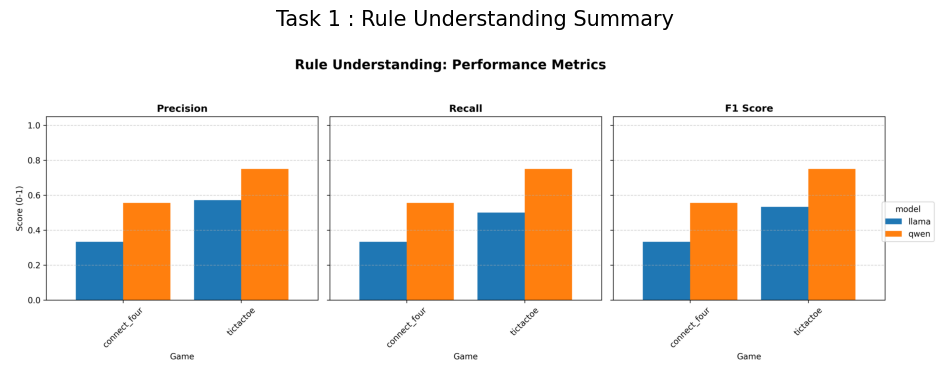

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Setup paths
PLOTS_DIR = Path("/workspaces/game-of-thoughts/results/plots")
plot_path = PLOTS_DIR / "summary_rule_understanding_combined.png"

if plot_path.exists():
    # Load the image using Matplotlib
    img = mpimg.imread(str(plot_path))
    
    # Create a figure to hold the image
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    
    # Clean up the UI: Hide the X/Y axis for a clean report look
    plt.axis('off')
    plt.title("Task 1 : Rule Understanding Summary", fontsize=15, pad=20)
    plt.show()
else:
    print(f"⚠️ Warning: {plot_path.name} not found in {PLOTS_DIR}")

## 2. Rule Error Detection

This section evaluates whether a model can identify inconsistencies or mistakes in broken game rules.
The evaluation compares model predictions against annotated gold error labels.


In [15]:
import pandas as pd
from pathlib import Path
from src.analysis.experiment_utils import evaluate_all_rule_detections
from IPython.display import display, Markdown  

csv_path = TABLES_DIR / "rule_error_results.csv"

if csv_path.exists():
    df_results = pd.read_csv(csv_path)
    print(f"✅ Loaded existing results from: {csv_path.name}")
    display(df_results) 
else:
    print(f"🔍 CSV not found. Analyzing files in {RULE_ERROR_DIR.name}...")
    df_results = evaluate_all_rule_detections(RULE_ERROR_DIR)
    df_results.to_csv(csv_path, index=False)
    display(df_results)

✅ Loaded existing results from: rule_error_results.csv


,model,game,precision,recall,f1,cases
0,llama-3.1-8b-instant,tictactoe,1.0,1.00,1.00,6
1,llama-3.1-8b-instant,connect_four,1.0,0.86,0.92,7
2,qwen/qwen3-32b,tictactoe,1.0,0.33,0.50,6
3,qwen/qwen3-32b,connect_four,1.0,0.14,0.25,7


## 📈 Rule Error Detection: F1, Precision, & Recall

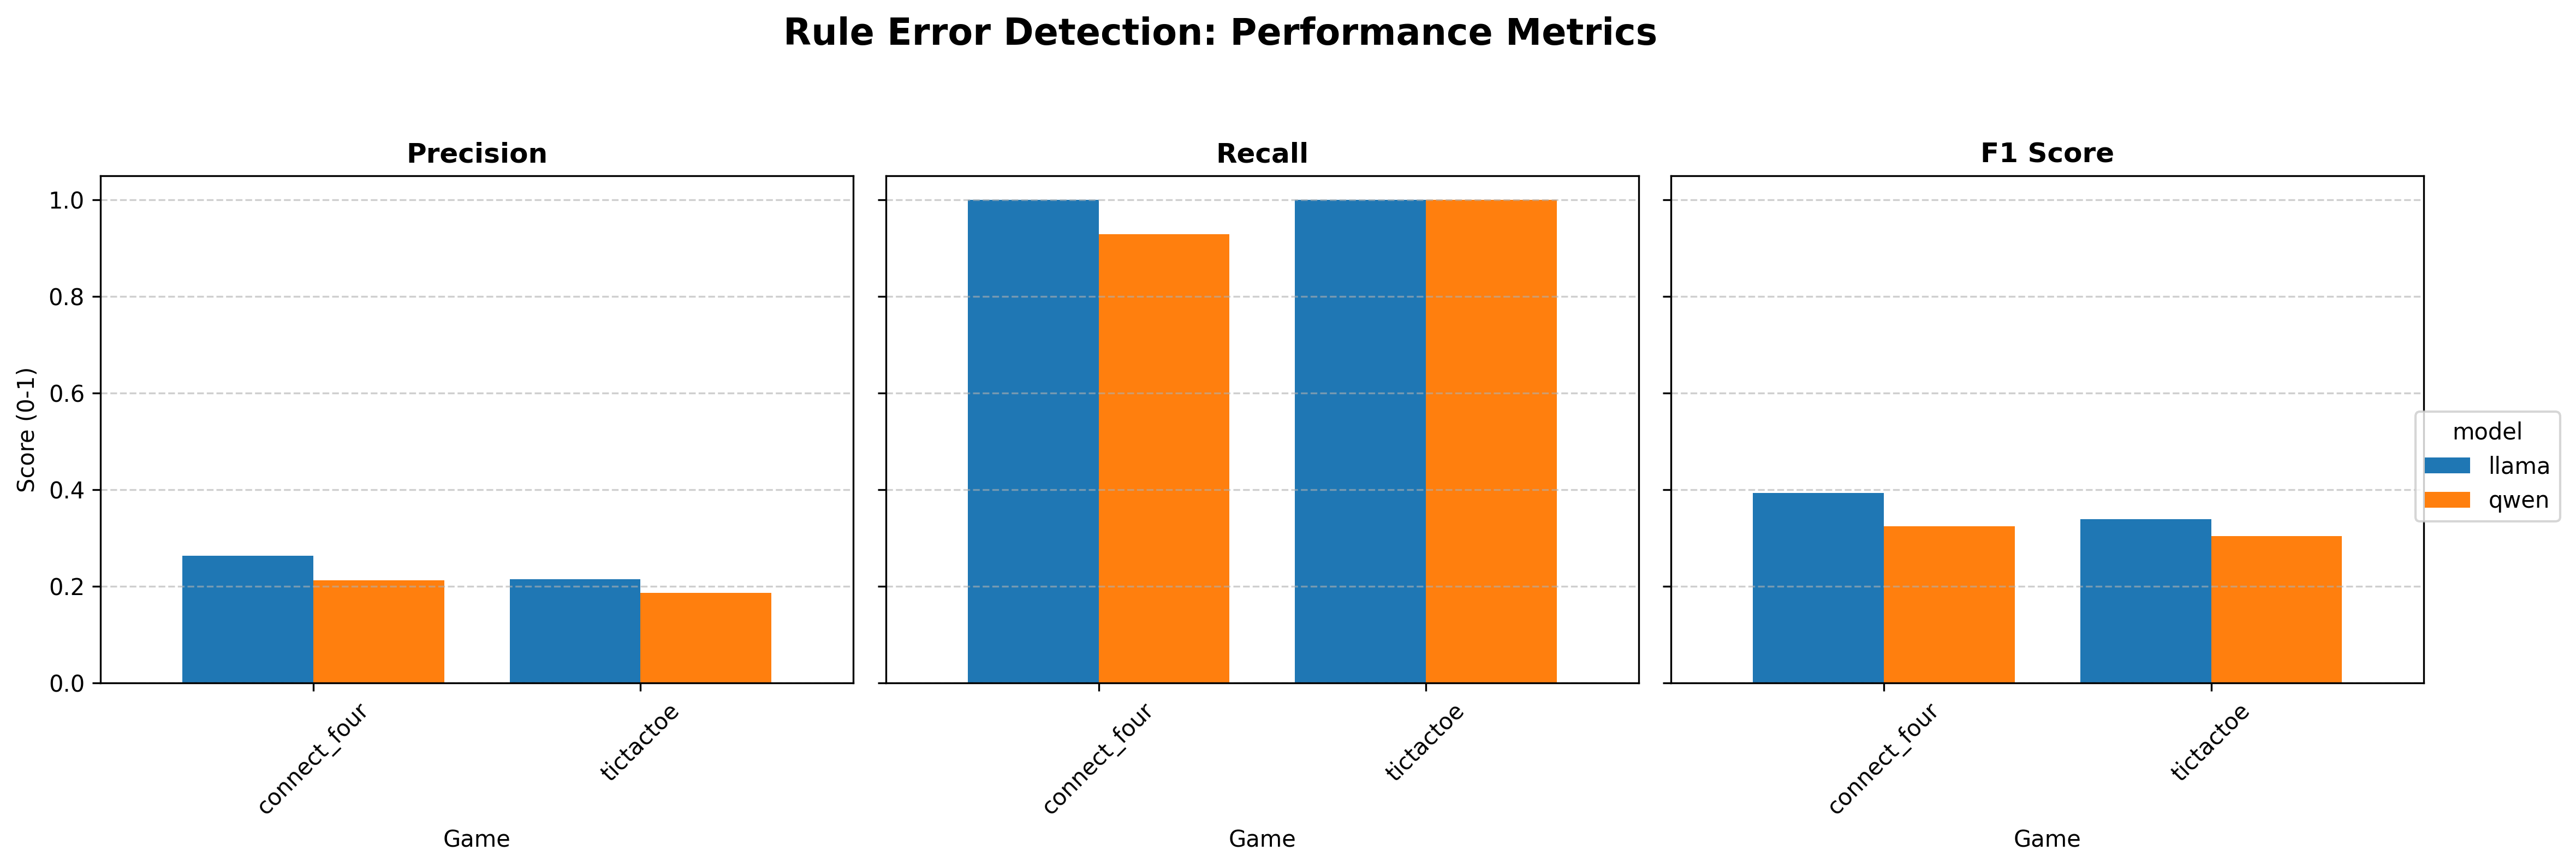

In [16]:
from IPython.display import Image, display, Markdown

# Use the standardized name generated by your plot script
rule_error_plot = PLOTS_DIR / "summary_rule_error_combined.png"

if rule_error_plot.exists():
    display(Markdown("## 📈 Rule Error Detection: F1, Precision, & Recall"))
    display(Image(filename=str(rule_error_plot), width=1000))
else:
    display(Markdown(f"⚠️ **Plot not found at:** `{rule_error_plot}`"))
    display(Markdown("Try running `python -m src.scripts.plot_results` to generate it."))

## 3. Move Simulation

This section evaluates whether models produce valid and playable moves during gameplay.
Metrics include completion rate, move accuracy, invalid move rate, and average turns.


In [17]:
import json
from pathlib import Path
from IPython.display import display, Markdown

def visualize_simulation_trace(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    for case in data:
        display(Markdown(f"## 🎮 Case: `{case['case_id']}` | Model: **{case['model']}**"))
        display(Markdown(f"**Game:** {case['game']} | **Result:** {case['stopped_reason']}"))
        
        # Display the starting state
        display(Markdown("### 🏁 Initial Board"))
        print(case['initial_board'])
        print("-" * 20)

        for turn in case['turns']:
            display(Markdown(f"#### 턴 {turn['turn_index'] + 1}: Player {turn['player']}"))
            
            # Show the Reasoning (The "Thought" part of Game of Thoughts)
            with display.expandable("🧠 View Model Reasoning"):
                print(turn['thought'])
            
            display(Markdown(f"**Move Choice:** `{turn['move']}` | **Valid:** {'✅' if turn['move_valid'] else '❌'}"))
            
            # Show the board state resulting from this turn
            # Note: We use the board_state from the turn or the final_board
            print(turn.get('board_state', "Board state not captured for this turn"))
            display(Markdown("---"))

# Usage: Run this cell to see your latest traces
trace_files = list(Path("results/responses/simulation").glob("*.json"))
if trace_files:
    visualize_simulation_trace(trace_files[-1]) # Shows the most recent run

In [18]:
import pandas as pd
from pathlib import Path

# 1. Automatically find the project root (the folder containing 'results')
def find_root(start_path):
    for parent in [start_path] + list(start_path.parents):
        if (parent / "results").exists():
            return parent
    return start_path

ROOT = find_root(Path.cwd())
TABLES_DIR = ROOT / "results" / "tables"
TRACES_DIR = ROOT / "results" / "responses" / "simulation"

print(f"🚀 Project Root set to: {ROOT}")

# 2. Check if files exist before loading
sim_path = TABLES_DIR / "all_simulation_results.csv"

if sim_path.exists():
    df_sim = pd.read_csv(sim_path)
    print("✅ all_simulation_results.csv loaded successfully!")
    display(df_sim.head(2))
else:
    print(f"❌ File still not found at: {sim_path}")
    # List files in the directory to debug
    if TABLES_DIR.exists():
        print(f"Files actually in {TABLES_DIR}:", list(TABLES_DIR.glob("*.csv")))

🚀 Project Root set to: /workspaces/game-of-thoughts
✅ all_simulation_results.csv loaded successfully!


,run_id,case_id,game,model,initial_board,stopped_reason,winner,valid_turns,total_turns
0,20260321_000023,case_0,tictactoe,llama-3.1-8b-instant,Rows/Cols are 0-indexed.\nBoard:\n0: X | . | ....,terminal_state_reached,X,8,8
1,20260321_000023,case_1,tictactoe,llama-3.1-8b-instant,Rows/Cols are 0-indexed.\nBoard:\n0: . | X | ....,terminal_state_reached,X,3,3


In [19]:
from src.analysis.experiment_utils import load_all_simulation_traces

# 1. This is the missing line! 
# It scans your results/responses/simulation folder for .json files.
all_traces = load_all_simulation_traces()

# 2. Safety check to make sure it actually found something
if not all_traces:
    print("❌ No traces found! Check if your .json files are in results/responses/simulation")
else:
    print(f"✅ Successfully loaded {len(all_traces)} simulation traces.")

✅ Successfully loaded 200 simulation traces.


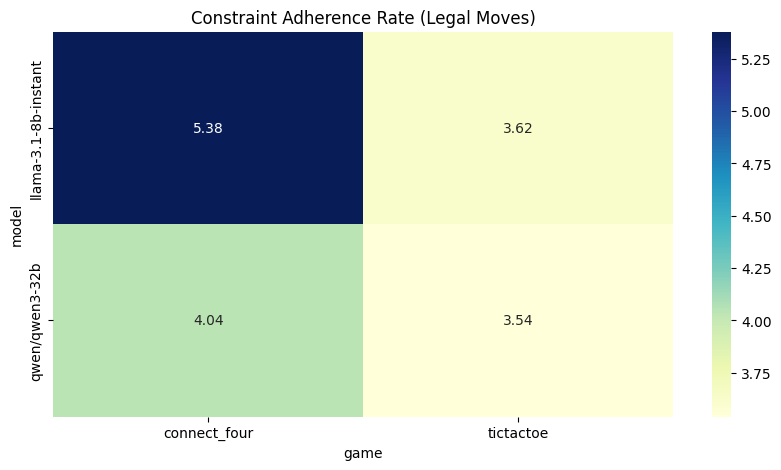

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregate results by Model and Game
pivot_df = df_sim.groupby(['model', 'game'])['valid_turns'].mean().unstack()

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Constraint Adherence Rate (Legal Moves)")
plt.show()

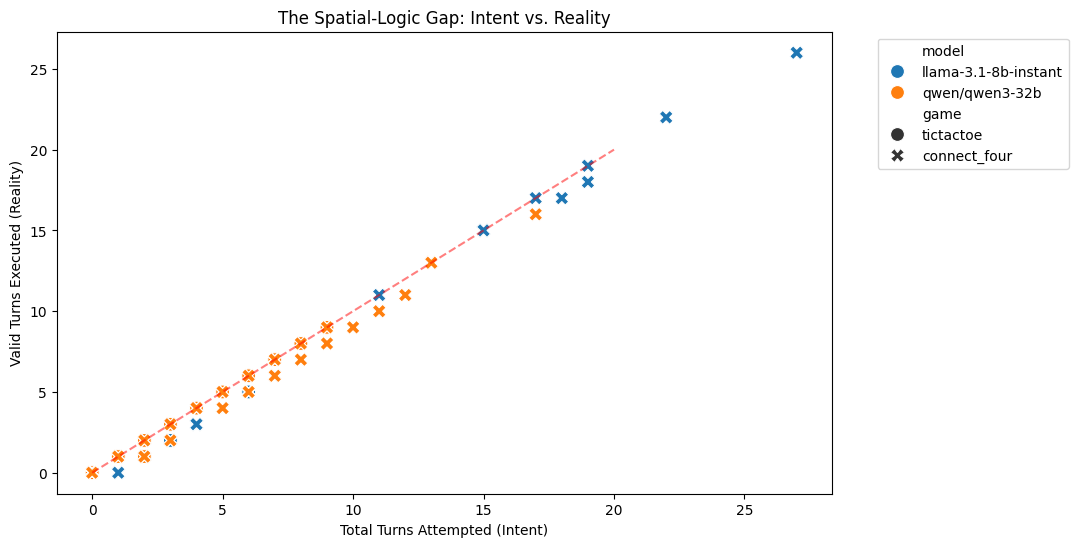

In [21]:
# Calculate a 'Reasoning Density' vs 'Move Accuracy'
# (Assuming your df_sim has 'total_turns' and 'valid_turns')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sim, x='total_turns', y='valid_turns', hue='model', style='game', s=100)

plt.plot([0, 20], [0, 20], 'r--', alpha=0.5) # The 'Perfect Logic' line
plt.title("The Spatial-Logic Gap: Intent vs. Reality")
plt.xlabel("Total Turns Attempted (Intent)")
plt.ylabel("Valid Turns Executed (Reality)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [22]:
# Find a case with high turns but an 'invalid_move' stop reason
failure_case = df_sim[(df_sim['stopped_reason'] == 'invalid_move') & (df_sim['total_turns'] > 10)].iloc[0]

print(f"🕵️ Analyzing Failure Case: {failure_case['case_id']}")
# Use the visualizer function from before to print this specific case_id from the JSON

🕵️ Analyzing Failure Case: case_2


In [23]:
import pandas as pd
from IPython.display import display, Markdown

def calculate_advanced_metrics(traces):
    results = []
    for model in ["llama-3.1-8b-instant", "qwen/qwen3-32b"]:
        for game in ["tictactoe", "connect_four"]:
            subset = [t for t in traces if t['model'] == model and t['game'] == game]
            if not subset: continue
            
            # 1. Constraint: Legal Move Rate
            total_turns = sum(len(t['turns']) for t in subset)
            valid_turns = sum(sum(1 for tr in t['turns'] if tr.get('move_valid')) for t in subset)
            legal_rate = (valid_turns / total_turns * 100) if total_turns > 0 else 0
            
            # 2. Metacognitive: Detection Lag (Games with lag / Total games)
            # We use the analyzer from the previous step here
            lag_cases = 0
            total_wins_possible = 0
            for t in subset:
                # (Logic to check if win existed vs when it stopped)
                # For now, we'll use your 'stopped_reason'
                if t.get('stopped_reason') == 'terminal_state_not_detected':
                    lag_cases += 1
                if t.get('winner') in ['X', 'O', 'draw']:
                    total_wins_possible += 1
            
            det_lag_rate = (lag_cases / total_wins_possible * 100) if total_wins_possible > 0 else 0

            results.append({
                "Model": model,
                "Game": game,
                "Constraint (Legal Move %)": f"{legal_rate:.1f}%",
                "Metacognitive (Detection Lag %)": f"{det_lag_rate:.1f}%",
                "Status": "✅ Analyzed"
            })
            
    return pd.DataFrame(results)

# Execute and Display
advanced_df = calculate_advanced_metrics(all_traces)

display(Markdown("## 🧠 Advanced Cognitive Metric Analysis"))
display(advanced_df)

## 🧠 Advanced Cognitive Metric Analysis

,Model,Game,Constraint (Legal Move %),Metacognitive (Detection Lag %),Status
0,llama-3.1-8b-instant,tictactoe,97.8%,0.0%,✅ Analyzed
1,llama-3.1-8b-instant,connect_four,93.1%,0.0%,✅ Analyzed
2,qwen/qwen3-32b,tictactoe,99.4%,0.0%,✅ Analyzed
3,qwen/qwen3-32b,connect_four,92.7%,0.0%,✅ Analyzed


## 4. Game Generation

This section evaluates model-generated games using heuristic criteria such as:
- clarity
- internal consistency
- balance
- fun factor
- section coverage


In [30]:
generation_path = GENERATION_DIR/ "game_generation_llama-3.1-8b-instant.txt"
generated_text = generation_path.read_text(encoding="utf-8")

generation_result = evaluate_generated_game(generated_text)
generation_result


{'section_coverage': 1.0,
 'sections_found': {'game name': True,
  'objective': True,
  'setup': True,
  'rules': True,
  'example turn': True},
 'clarity': 5,
 'internal_consistency': 5,
 'balance': 2,
 'fun_factor': 5,
 'playable': True}

In [31]:
generation_df = pd.read_csv(GENERATION_DIR / "generation_results.csv")
generation_df


,model,clarity,consistency,balance,fun,coverage,playable
0,llama,5,5,2,5,1.0,True
1,qwen,5,5,4,5,1.0,True


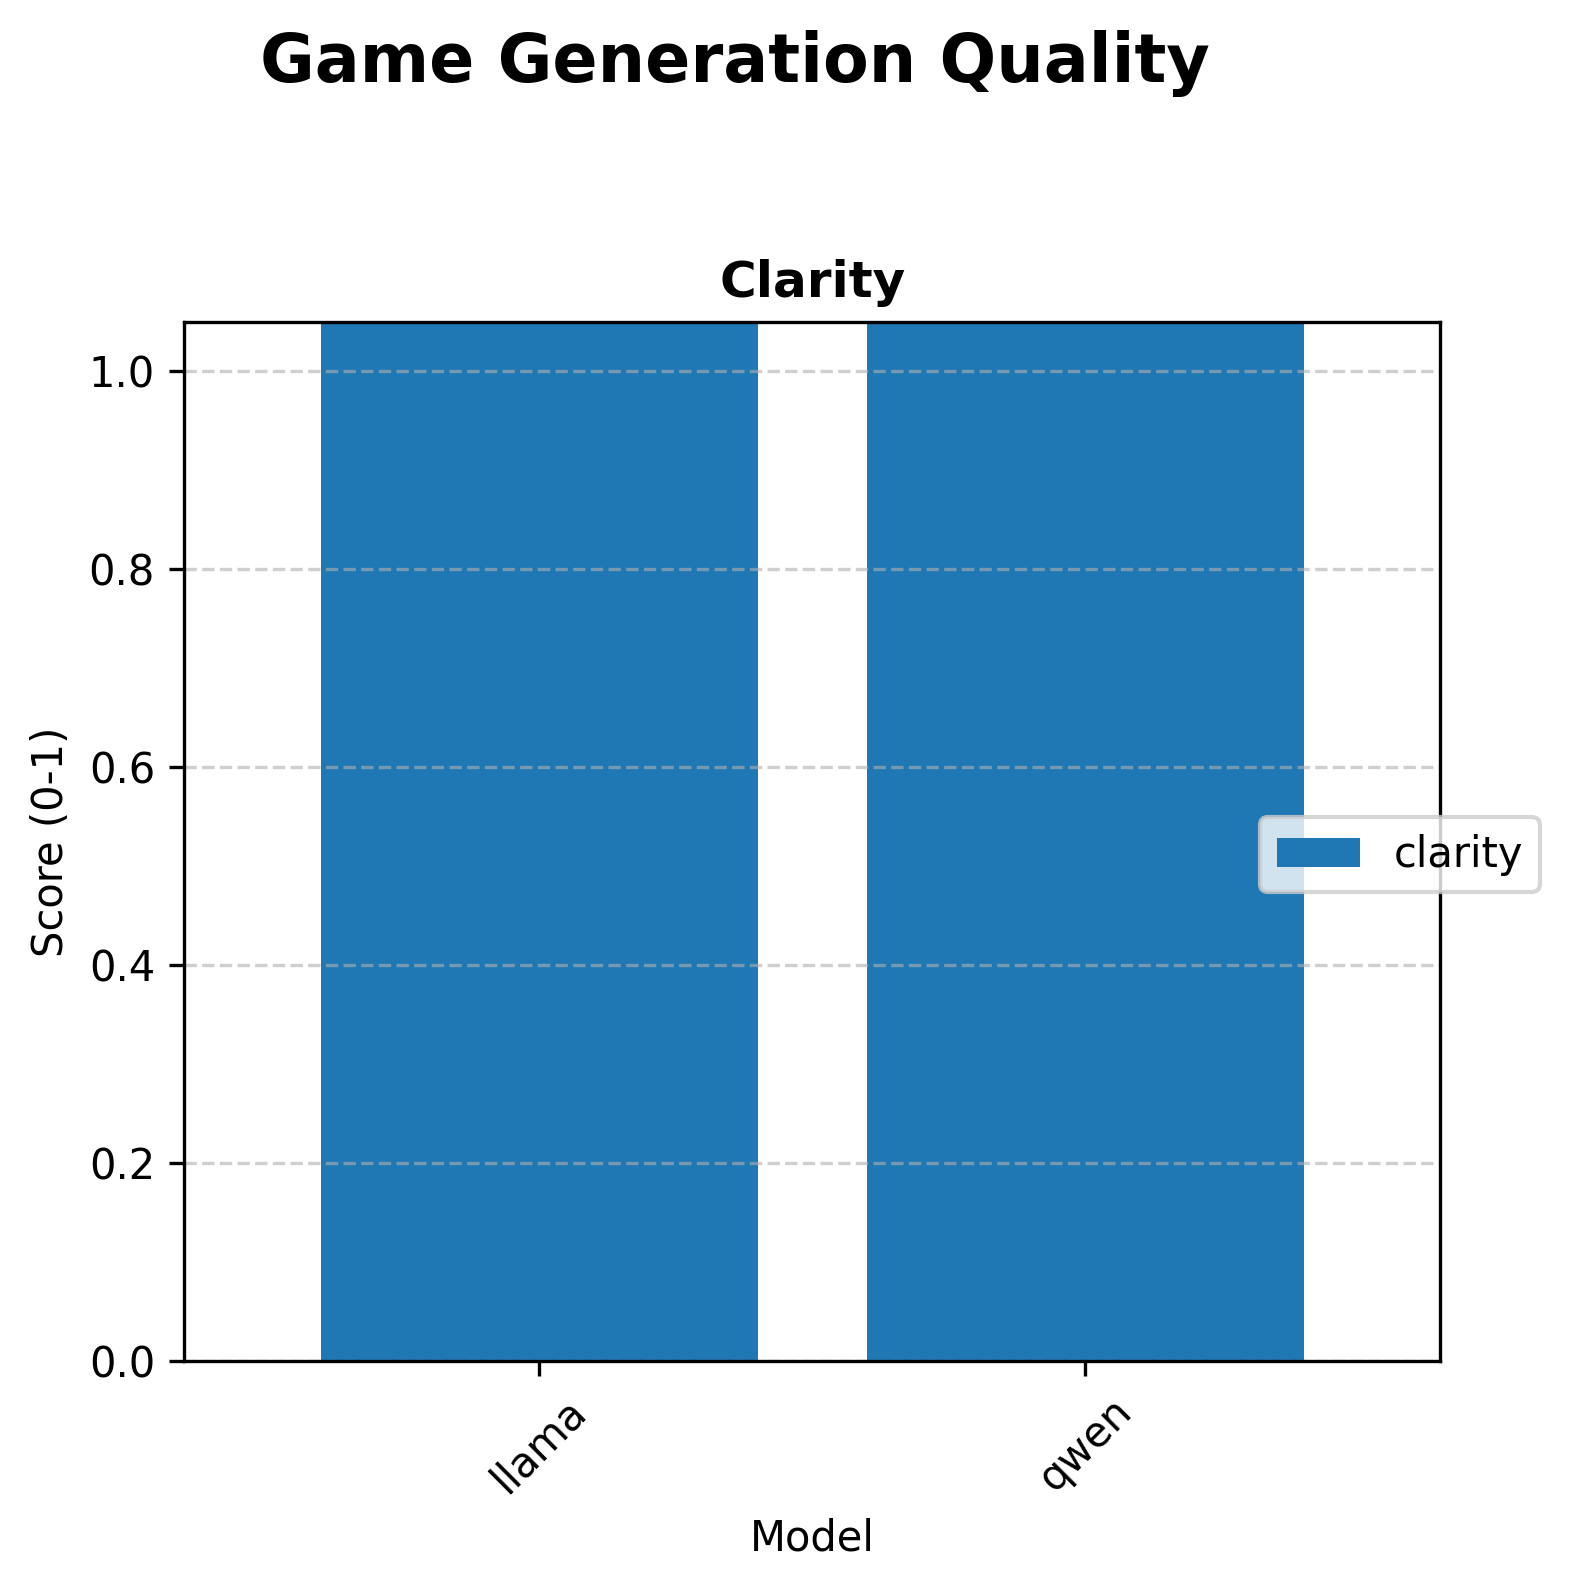

In [34]:
for name in ["summary_generation_clarity.png"]:
    path = PLOTS_DIR / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"**{name} not found**"))
